In [1]:
import pandas as pd

# a) wczytanie
df = pd.read_csv("weather_Portland.csv")

# wymuszamy typ numeryczny na kolumnach ciśnienia zaraz po wczytaniu
df["Pressure9am"] = pd.to_numeric(df["Pressure9am"], errors="coerce")
df["Pressure3pm"] = pd.to_numeric(df["Pressure3pm"], errors="coerce")

# b) usunięcie zbędnych kolumn
kolumny_do_usuniecia = ["Date", "Location", "Evaporation", "Sunshine", "RainToday", "RISK_MM"]
df = df.drop(columns=kolumny_do_usuniecia)

# c) usunięcie wierszy bez etykiety
df = df.dropna(subset=["RainTomorrow"])

# d) tylko wiersze z max 2 brakami
df = df[df.isnull().sum(axis=1) <= 2]

df.head()

,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,12.5,16.6,0.0,SW,59.0,SW,SW,28.0,28.0,97.0,99.0,1006.7,1010.5,NaN,6.0,13.7,14.5,Yes
1,8.6,15.2,1.6,SSW,39.0,SW,S,20.0,17.0,60.0,61.0,1020.0,1021.3,6.0,2.0,11.9,14.0,No
2,1.6,18.0,0.2,S,30.0,NE,ESE,9.0,15.0,67.0,52.0,1020.4,1018.3,6.0,3.0,11.6,17.5,No
3,4.8,20.1,0.0,S,28.0,E,S,11.0,17.0,73.0,63.0,1016.4,1015.2,1.0,1.0,14.7,18.1,No
4,4.4,18.8,0.0,W,46.0,W,W,20.0,31.0,72.0,68.0,1014.0,1013.4,4.0,3.0,14.9,18.0,No


In [2]:
# a) uzupełnianie braków
kolumny_num = df.select_dtypes(include="number").columns
kolumny_kat = df.select_dtypes(include="object").columns

for kolumna in kolumny_num:
    mediana = df[kolumna].median()
    df[kolumna] = df[kolumna].fillna(mediana)

for kolumna in kolumny_kat:
    moda = df[kolumna].mode()[0]
    df[kolumna] = df[kolumna].fillna(moda)

# b) kategoryzacja ciśnienia
przedzialy = [-float("inf"), 980, 1000, 1020, 1040, float("inf")]
nazwy = ["bardzo_niskie", "niskie", "normalne", "wysokie", "bardzo_wysokie"]

for kolumna in ["Pressure9am", "Pressure3pm"]:
    # najpierw konwertujemy na liczby (errors="coerce" zamienia nieczytelne wartości na NaN)
    df[kolumna] = pd.to_numeric(df[kolumna], errors="coerce")
    # uzupełniamy ewentualne NaN-y które powstały po konwersji
    df[kolumna] = df[kolumna].fillna(df[kolumna].median())
    # teraz dopiero kategoryzujemy
    df[kolumna] = pd.cut(
        df[kolumna],
        bins=przedzialy,
        labels=nazwy
    )

df[["Pressure9am", "Pressure3pm"]].value_counts()

Pressure9am  Pressure3pm
normalne     normalne       2631
wysokie      wysokie        1570
             normalne        350
normalne     wysokie          95
niskie       niskie           74
normalne     niskie           54
niskie       normalne         16
Name: count, dtype: int64

In [3]:
# a) podział na X i y
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

# b) przycinanie wartości odstających
kolumny_num = X.select_dtypes(include="number").columns

for kolumna in kolumny_num:
    srednia = X[kolumna].mean()
    odch_std = X[kolumna].std()
    dolna_granica = srednia - 3 * odch_std
    gorna_granica = srednia + 3 * odch_std
    X[kolumna] = X[kolumna].clip(lower=dolna_granica, upper=gorna_granica)
    
X.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000,4790.000000
mean,9.510008,17.866851,2.288873,42.396169,16.564528,20.939840,78.905937,65.695164,6.785599,6.431240,13.051719,16.313727
std,3.594562,4.949144,4.082573,14.818936,7.973818,8.359185,13.812823,14.836580,1.998333,2.047341,3.679066,4.652621
min,-1.283594,9.000000,0.000000,13.000000,0.000000,0.000000,37.037835,20.856381,0.750749,0.272923,1.783983,5.200000
25%,7.000000,14.200000,0.000000,31.000000,11.000000,15.000000,69.000000,57.000000,6.000000,6.000000,10.600000,12.900000
50%,9.500000,16.800000,0.200000,40.000000,15.000000,20.000000,81.000000,66.000000,8.000000,7.000000,12.800000,15.400000
75%,12.000000,20.200000,2.600000,52.000000,20.000000,26.000000,90.000000,75.000000,8.000000,8.000000,15.300000,18.700000
max,20.305599,33.334642,17.976040,87.383316,40.942938,46.364272,100.000000,100.000000,8.000000,8.000000,24.366288,30.857866


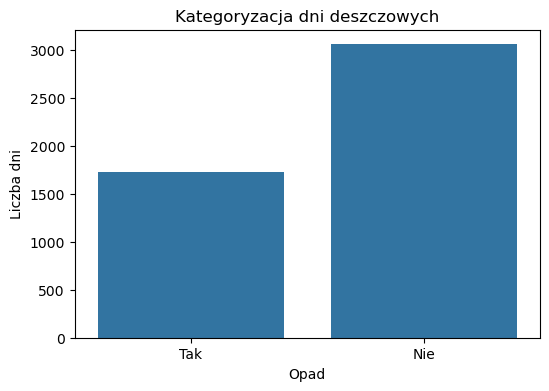

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# a) zamieniamy wartości Yes/No na Tak/Nie
y_plot = y.map({"Yes": "Tak", "No": "Nie"})

# tworzymy wykres słupkowy
plt.figure(figsize=(6, 4))  # rozmiar wykresu w calach
sns.countplot(x=y_plot)

# b) etykiety osi
plt.xlabel("Opad")
plt.ylabel("Liczba dni")

# c) tytuł
plt.title("Kategoryzacja dni deszczowych")

# d) wyświetlamy
plt.show()

In [5]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, MinMaxScaler

# a) kodowanie porządkowe
kolejnosc = [["bardzo_niskie", "niskie", "normalne", "wysokie", "bardzo_wysokie"]]
enc_ordinal = OrdinalEncoder(categories=kolejnosc * 2)
kolumny_porz = ["Pressure9am", "Pressure3pm"]
X[kolumny_porz] = enc_ordinal.fit_transform(X[kolumny_porz])

# b) kodowanie nominalne
kolumny_nom = ["WindGustDir", "WindDir9am", "WindDir3pm"]
X = pd.get_dummies(X, columns=kolumny_nom)

# c) kodowanie zmiennej celu
enc_label = LabelEncoder()
y = enc_label.fit_transform(y)

# d) skalowanie do [0,1]
scaler = MinMaxScaler()
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X.head()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.638449,0.312312,0.000000,0.618418,0.683879,0.603913,0.952352,0.987365,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.457803,0.254781,0.089007,0.349541,0.488485,0.366662,0.364698,0.507225,0.5,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133567,0.369843,0.011126,0.228546,0.219818,0.323525,0.475876,0.393508,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.281789,0.456140,0.000000,0.201658,0.268667,0.366662,0.571171,0.532495,0.5,0.5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.263261,0.402718,0.000000,0.443648,0.488485,0.668618,0.555288,0.595672,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# a) podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# b) tworzenie i trenowanie modeli
knn     = KNeighborsClassifier()
dt      = DecisionTreeClassifier(max_depth=4)
lr      = LogisticRegression(penalty=None)
svm_lin = SVC(kernel="linear", C=1000)
svm_rbf = SVC(kernel="rbf")

knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm_lin.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

# c) predykcja
y_train_preds = {
    "KNN":     knn.predict(X_train),
    "DT":      dt.predict(X_train),
    "LR":      lr.predict(X_train),
    "SVM_lin": svm_lin.predict(X_train),
    "SVM_rbf": svm_rbf.predict(X_train)
}

y_test_preds = {
    "KNN":     knn.predict(X_test),
    "DT":      dt.predict(X_test),
    "LR":      lr.predict(X_test),
    "SVM_lin": svm_lin.predict(X_test),
    "SVM_rbf": svm_rbf.predict(X_test)
}

         acc_train  acc_test  prc_train  prc_test  rcl_train  rcl_test
KNN       0.820198  0.697286   0.796596  0.599291   0.675325  0.488439
DT        0.793841  0.766180   0.786538  0.747967   0.590188  0.531792
LR        0.803497  0.774530   0.760494  0.727273   0.666667  0.601156
SVM_lin   0.801409  0.772443   0.761069  0.722222   0.657287  0.601156
SVM_rbf   0.834029  0.773486   0.815126  0.738007   0.699856  0.578035

Najlepszy model: LR


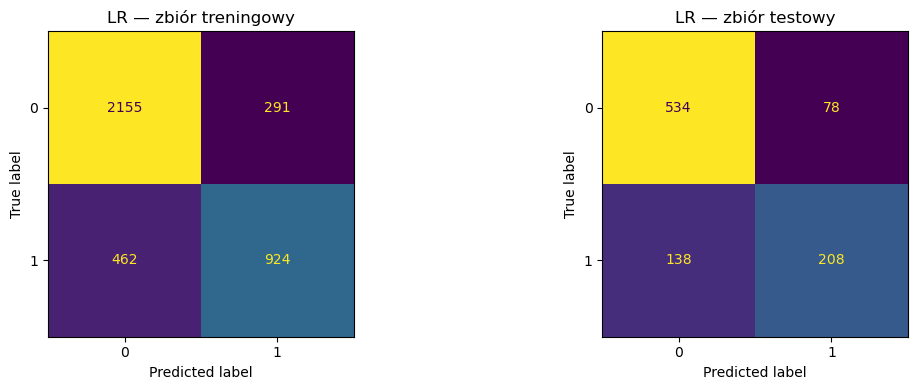

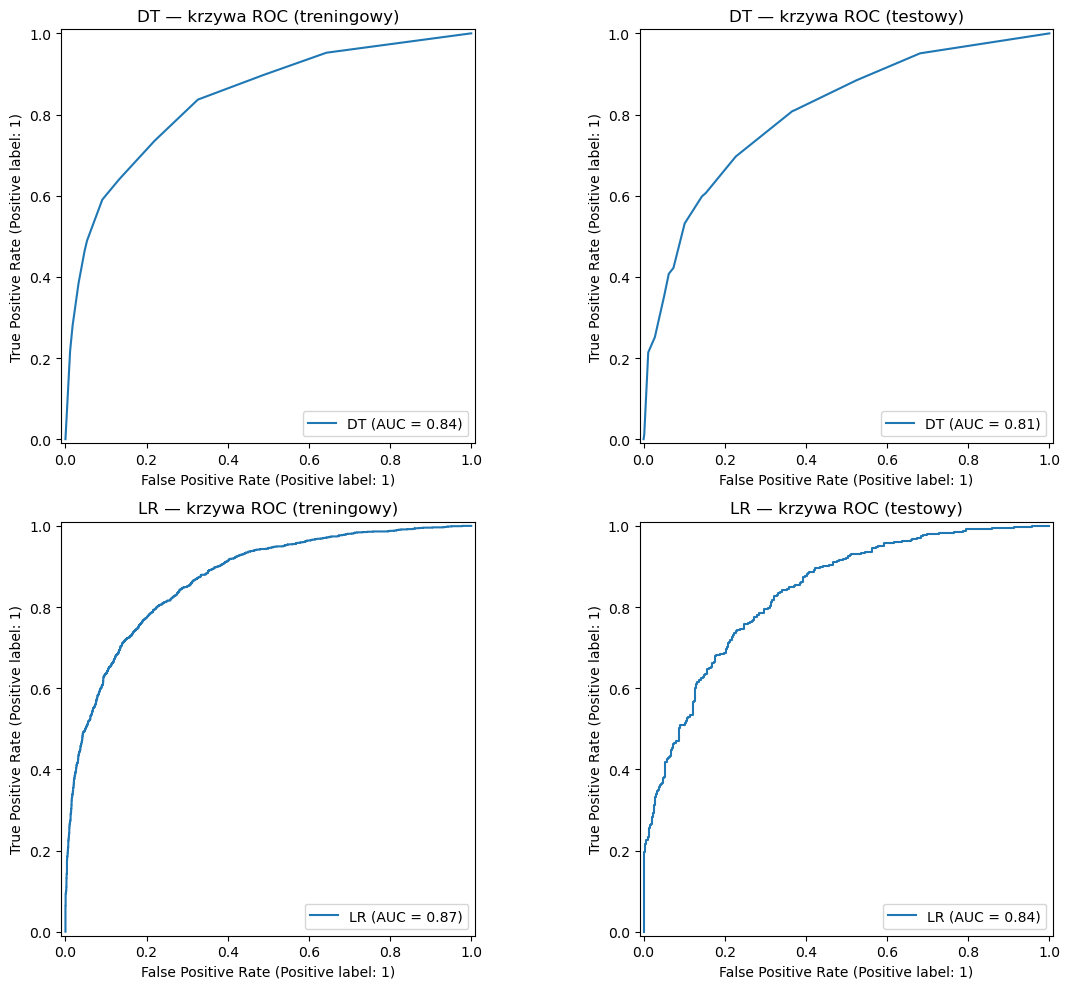

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# a) i b) tabela metryk
nazwy = ["KNN", "DT", "LR", "SVM_lin", "SVM_rbf"]
wyniki = []

for nazwa in nazwy:
    wyniki.append({
        "acc_train": accuracy_score(y_train, y_train_preds[nazwa]),
        "acc_test":  accuracy_score(y_test,  y_test_preds[nazwa]),
        "prc_train": precision_score(y_train, y_train_preds[nazwa]),
        "prc_test":  precision_score(y_test,  y_test_preds[nazwa]),
        "rcl_train": recall_score(y_train, y_train_preds[nazwa]),
        "rcl_test":  recall_score(y_test,  y_test_preds[nazwa]),
    })

df_wyniki = pd.DataFrame(wyniki, index=nazwy)
print(df_wyniki)

# c) macierz pomyłek
najlepszy = df_wyniki["acc_test"].idxmax()
print(f"\nNajlepszy model: {najlepszy}")

modele = {"KNN": knn, "DT": dt, "LR": lr, "SVM_lin": svm_lin, "SVM_rbf": svm_rbf}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_preds[najlepszy],
    ax=axes[0], colorbar=False
)
axes[0].set_title(f"{najlepszy} — zbiór treningowy")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_preds[najlepszy],
    ax=axes[1], colorbar=False
)
axes[1].set_title(f"{najlepszy} — zbiór testowy")
plt.tight_layout()
plt.show()

# d) krzywe ROC
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (nazwa, model) in enumerate([("DT", dt), ("LR", lr)]):
    RocCurveDisplay.from_estimator(
        model, X_train, y_train,
        ax=axes[i][0], name=nazwa
    )
    axes[i][0].set_title(f"{nazwa} — krzywa ROC (treningowy)")

    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        ax=axes[i][1], name=nazwa
    )
    axes[i][1].set_title(f"{nazwa} — krzywa ROC (testowy)")

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# a) wczytanie
df = pd.read_csv("housing.csv")

# b) informacje i statystyki
print(df.info())
print("\n")
print(df.describe())

# c) unikalne wartości ocean_proximity
print("\n")
print(df["ocean_proximity"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.1359

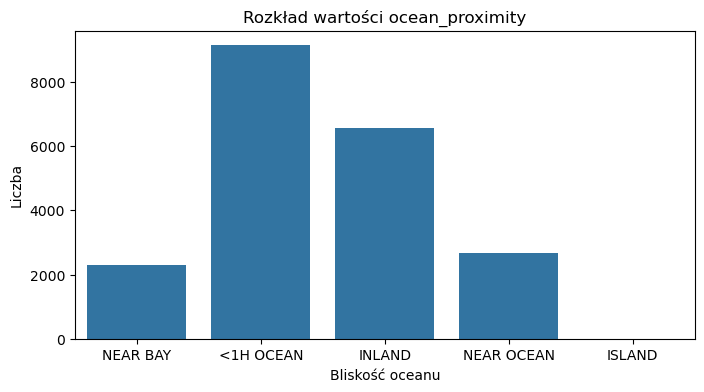

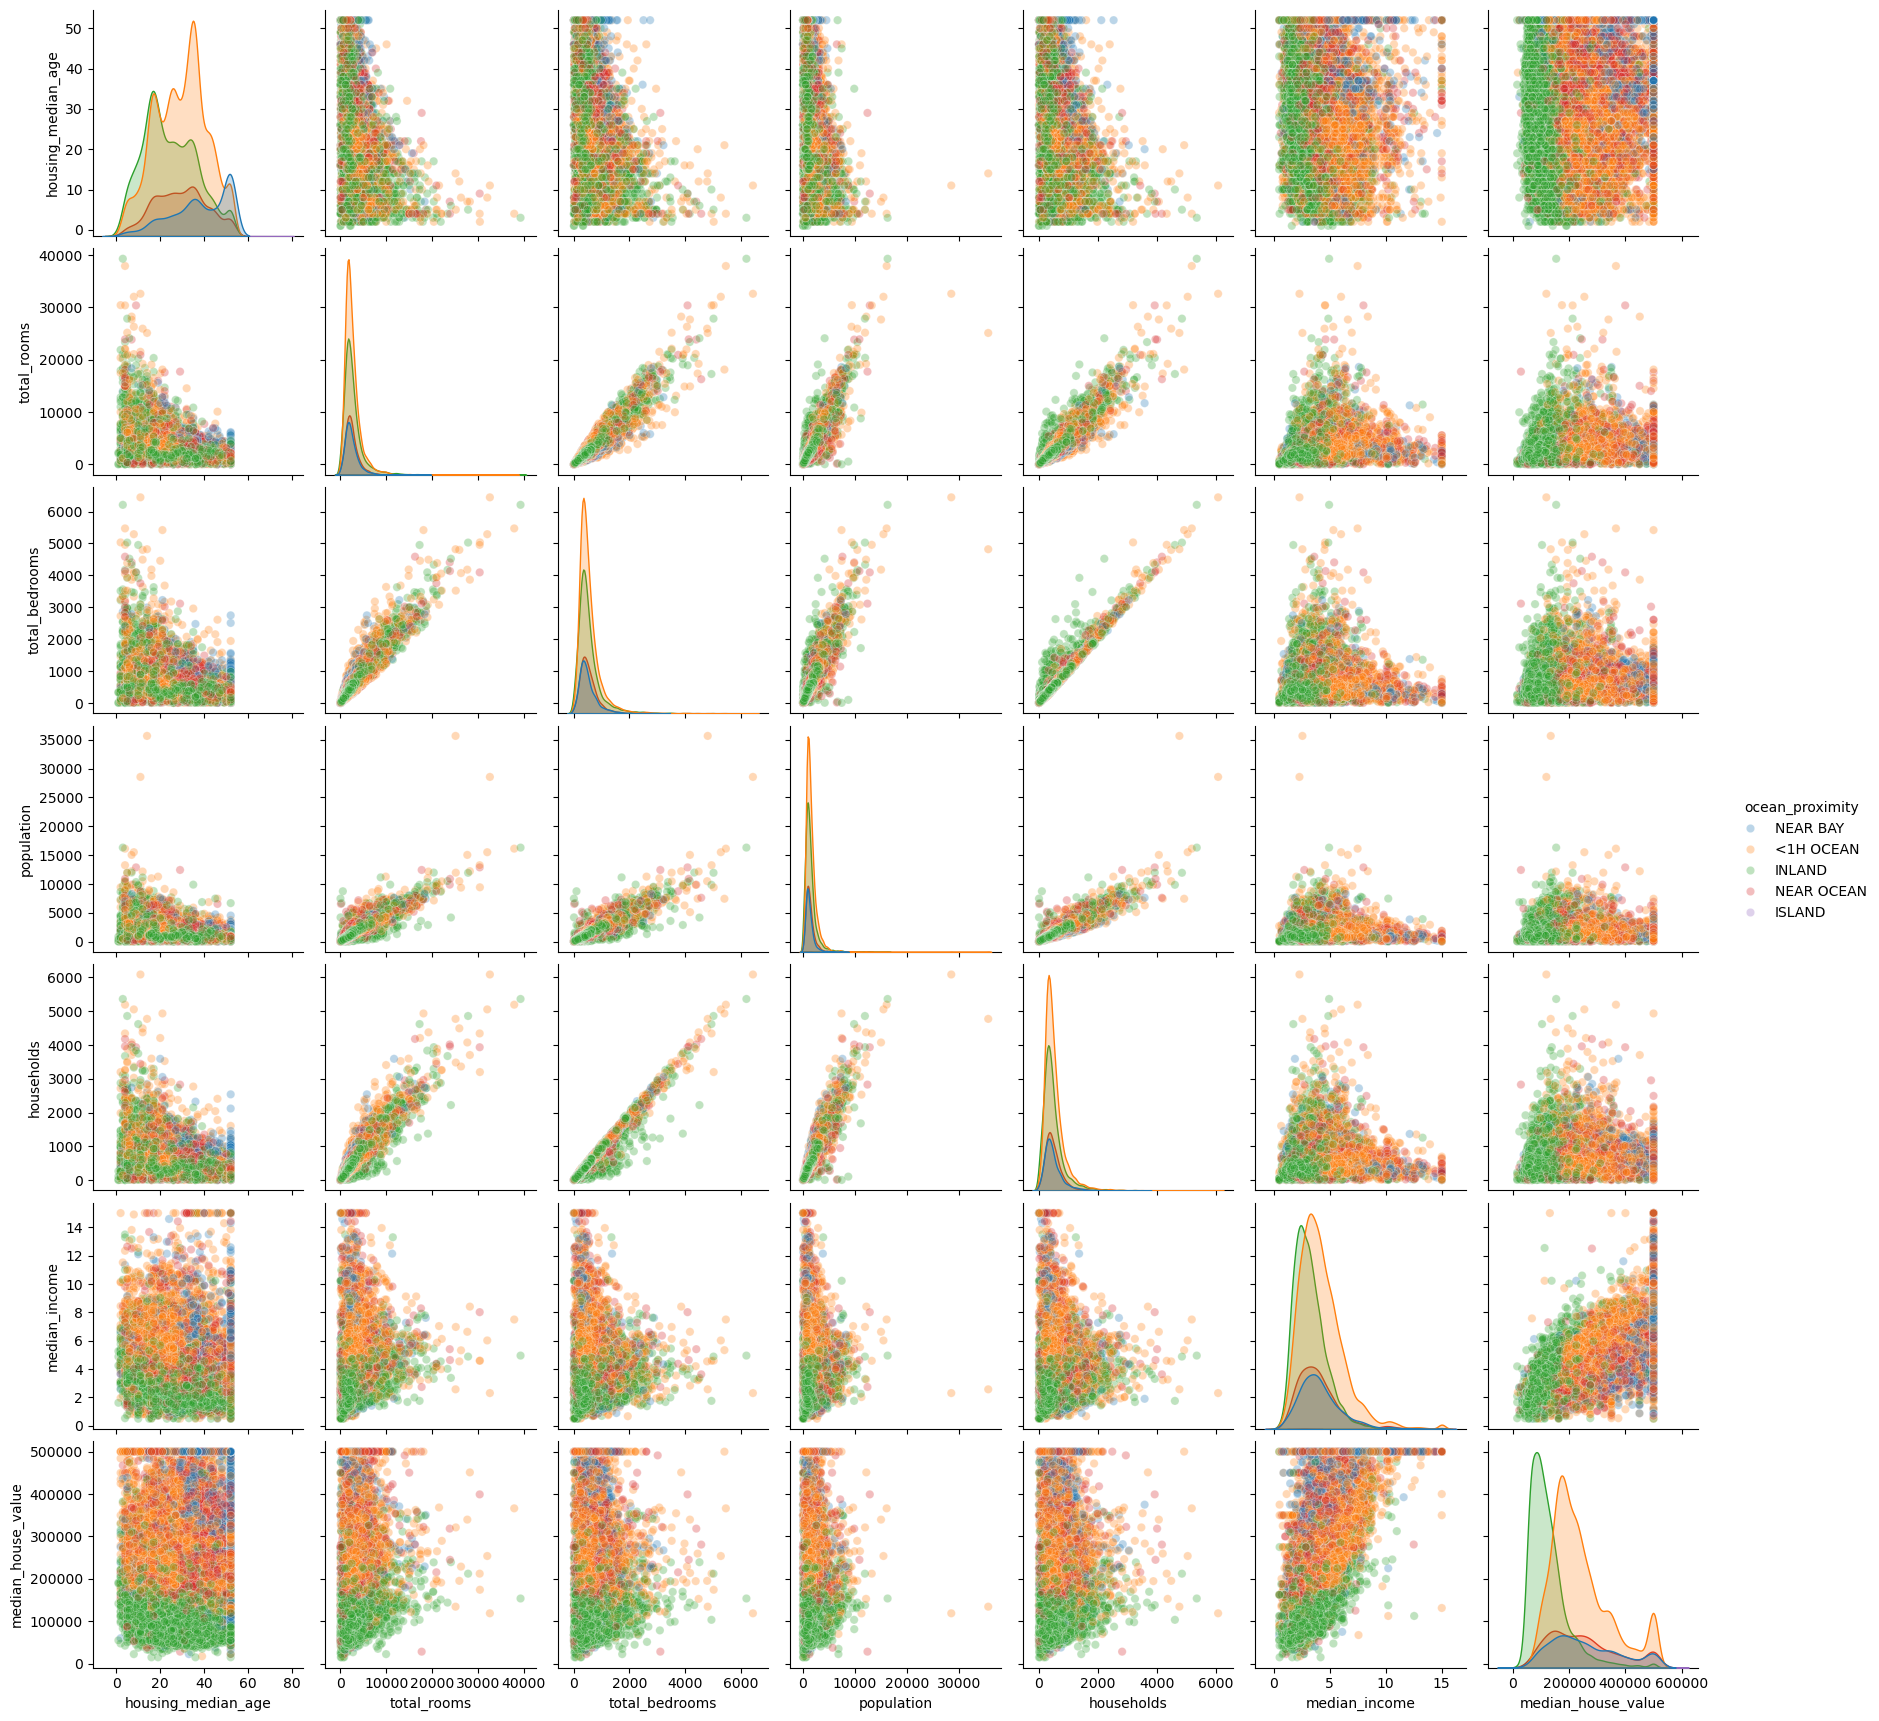

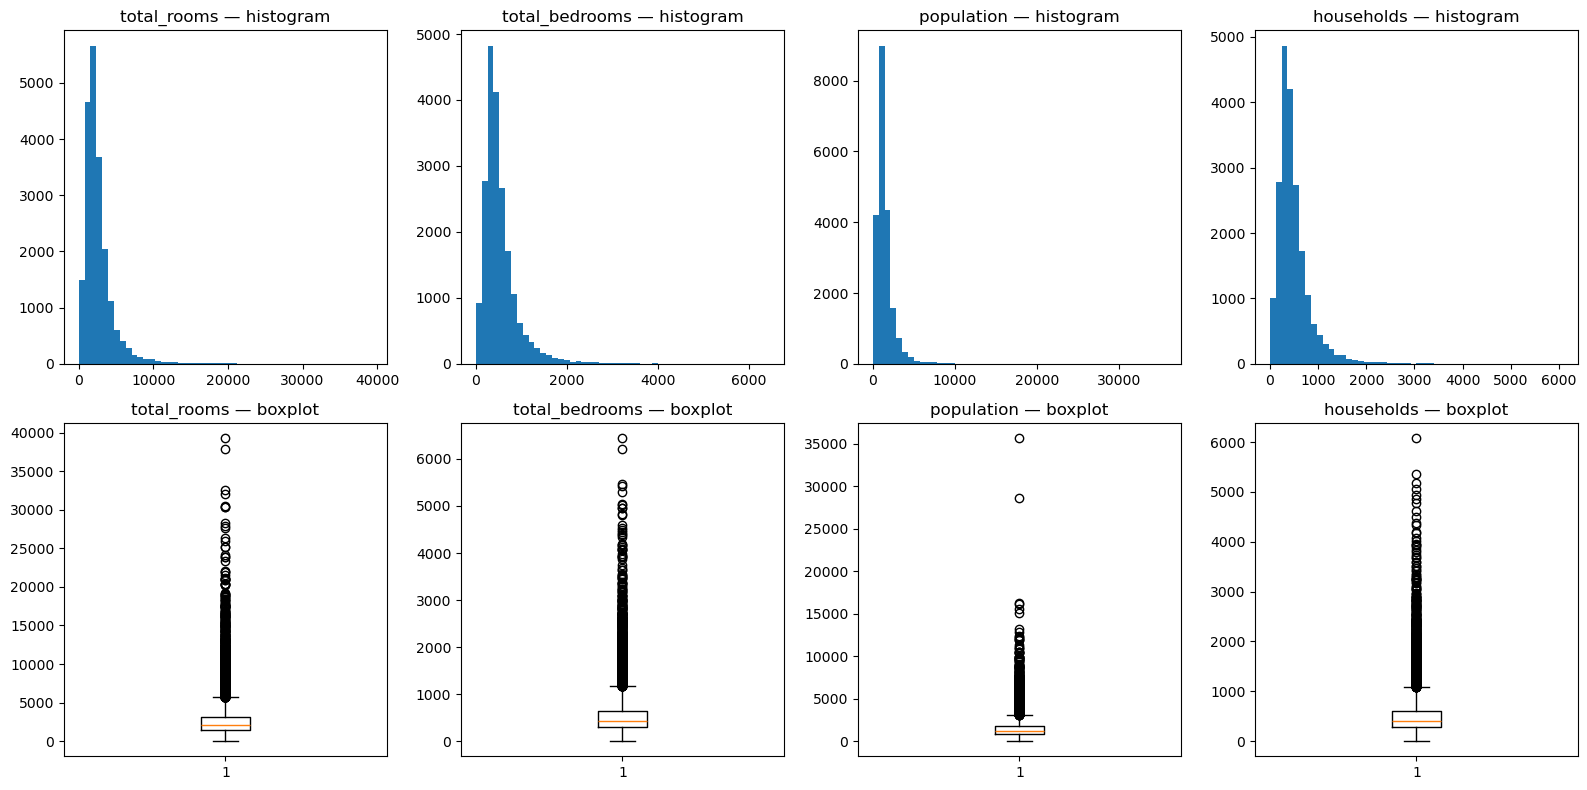

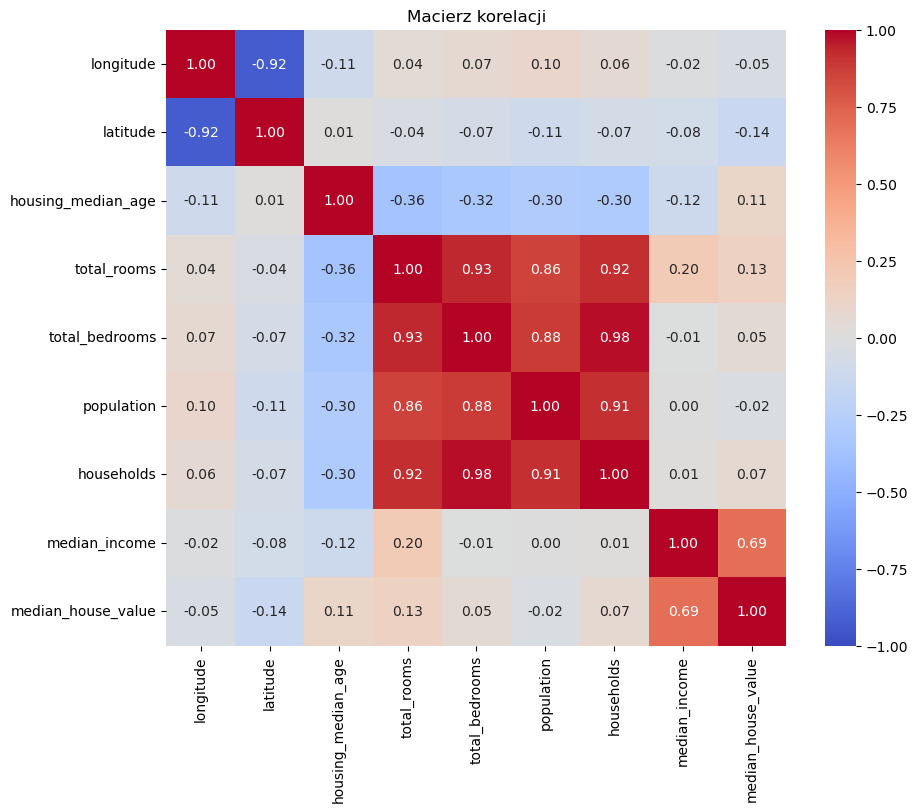

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) wykres słupkowy
plt.figure(figsize=(8, 4))
sns.countplot(x="ocean_proximity", data=df)
plt.title("Rozkład wartości ocean_proximity")
plt.xlabel("Bliskość oceanu")
plt.ylabel("Liczba")
plt.show()

# b) pairplot
kolumny_pairplot = [col for col in df.columns if col not in ["longitude", "latitude"]]
sns.pairplot(
    df[kolumny_pairplot],
    hue="ocean_proximity",
    plot_kws={"alpha": 0.3}
)
plt.show()

# c) histogramy i boxploty
kolumny_outliery = ["total_rooms", "total_bedrooms", "population", "households"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, kolumna in enumerate(kolumny_outliery):
    axes[0][i].hist(df[kolumna].dropna(), bins=50)
    axes[0][i].set_title(f"{kolumna} — histogram")
    axes[1][i].boxplot(df[kolumna].dropna())
    axes[1][i].set_title(f"{kolumna} — boxplot")

plt.tight_layout()
plt.show()

# d) macierz korelacji
korelacja = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    korelacja,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Macierz korelacji")
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

# a) zmienne skorelowane z total_bedrooms
kolumny_skorelowane = ["households", "total_rooms", "population"]

# b) wektor indeksów wierszy z brakami
rows_NA = df["total_bedrooms"].isnull()

# c) dane kompletne — cechy
X_OK = df.loc[~rows_NA, kolumny_skorelowane]

# d) dane kompletne — zmienna celu
y_OK = df.loc[~rows_NA, "total_bedrooms"]

# e) trenowanie modelu
model_lr = LinearRegression()
model_lr.fit(X_OK, y_OK)

# f) dane z brakami
X_NA = df.loc[rows_NA, kolumny_skorelowane]

# g) predykcja i uzupełnienie
przewidywane = model_lr.predict(X_NA)
df.loc[rows_NA, "total_bedrooms"] = przewidywane

# h) weryfikacja
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [11]:
from sklearn.preprocessing import PolynomialFeatures

# a) podział na X i y
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

# b) przycinanie wartości odstających
kolumny_outliery = ["total_rooms", "total_bedrooms", "population", "households"]

for kolumna in kolumny_outliery:
    srednia = X[kolumna].mean()
    odch_std = X[kolumna].std()
    dolna = srednia - 3 * odch_std
    gorna = srednia + 3 * odch_std
    X[kolumna] = X[kolumna].clip(lower=dolna, upper=gorna)

# c) kodowanie ocean_proximity
mapping = {
    "INLAND":     0,
    "NEAR BAY":   1,
    "NEAR OCEAN": 1,
    "<1H OCEAN":  2,
    "ISLAND":     1
}
X["ocean_proximity"] = X["ocean_proximity"].map(mapping)

# d) generacja cech wielomianowych
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_2 = pd.DataFrame(
    poly2.fit_transform(X),
    columns=poly2.get_feature_names_out(X.columns)
)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_3 = pd.DataFrame(
    poly3.fit_transform(X),
    columns=poly3.get_feature_names_out(X.columns)
)

print(f"Liczba cech X:   {X.shape[1]}")
print(f"Liczba cech X_2: {X_2.shape[1]}")
print(f"Liczba cech X_3: {X_3.shape[1]}")

Liczba cech X:   9
Liczba cech X_2: 54
Liczba cech X_3: 219


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# a) podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_2_train, X_2_test, _, _ = train_test_split(
    X_2, y, test_size=0.2, random_state=42
)

X_3_train, X_3_test, _, _ = train_test_split(
    X_3, y, test_size=0.2, random_state=42
)

# b) trenowanie modeli
lr1 = LinearRegression()
lr1.fit(X_train, y_train)

lr2 = LinearRegression()
lr2.fit(X_2_train, y_train)

lr3 = LinearRegression()
lr3.fit(X_3_train, y_train)

# c) predykcja
y_train_preds = {
    "LR1": lr1.predict(X_train),
    "LR2": lr2.predict(X_2_train),
    "LR3": lr3.predict(X_3_train)
}

y_test_preds = {
    "LR1": lr1.predict(X_test),
    "LR2": lr2.predict(X_2_test),
    "LR3": lr3.predict(X_3_test)
}

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

nazwy = ["LR1", "LR2", "LR3"]
wyniki = []

for nazwa in nazwy:
    wyniki.append({
        "MAE_train":  mean_absolute_error(y_train, y_train_preds[nazwa]),
        "MAE_test":   mean_absolute_error(y_test,  y_test_preds[nazwa]),
        "RMSE_train": root_mean_squared_error(y_train, y_train_preds[nazwa]),
        "RMSE_test":  root_mean_squared_error(y_test,  y_test_preds[nazwa]),
        "R2_train":   r2_score(y_train, y_train_preds[nazwa]),
        "R2_test":    r2_score(y_test,  y_test_preds[nazwa]),
    })

df_wyniki = pd.DataFrame(wyniki, index=nazwy)
print(df_wyniki)

        MAE_train      MAE_test    RMSE_train     RMSE_test  R2_train  \
LR1  49327.299149  50019.043443  67549.911008  68602.112835  0.658658   
LR2  43251.467899  43853.830230  60884.835241  62086.641102  0.722694   
LR3  39907.123686  40810.728097  57114.577421  59187.325667  0.755975   

      R2_test  
LR1  0.640856  
LR2  0.705836  
LR3  0.732668  


In [14]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

# nowy X z one-hot encoding zamiast porządkowego
X_new = df.drop(columns=["median_house_value"])

# przycinanie wartości odstających (tak samo jak w zadaniu 11)
kolumny_outliery = ["total_rooms", "total_bedrooms", "population", "households"]
for kolumna in kolumny_outliery:
    srednia = X_new[kolumna].mean()
    odch_std = X_new[kolumna].std()
    X_new[kolumna] = X_new[kolumna].clip(
        lower=srednia - 3*odch_std,
        upper=srednia + 3*odch_std
    )

# b) one-hot encoding zamiast porządkowego
X_new = pd.get_dummies(X_new, columns=["ocean_proximity"])

print(f"Liczba cech X_new: {X_new.shape[1]}")

# generacja cech dla stopni 2, 3, 4, 5
X_polys = {}
for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_polys[degree] = pd.DataFrame(
        poly.fit_transform(X_new),
        columns=poly.get_feature_names_out(X_new.columns)
    )
    print(f"Liczba cech stopień {degree}: {X_polys[degree].shape[1]}")
    
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# podział bazowego X_new
X_new_train, X_new_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

# trenowanie dla każdego stopnia
modele_new = {}
preds_train_new = {}
preds_test_new = {}

for degree in [2, 3, 4, 5]:
    X_poly_train, X_poly_test, _, _ = train_test_split(
        X_polys[degree], y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    modele_new[degree] = model
    preds_train_new[degree] = model.predict(X_poly_train)
    preds_test_new[degree] = model.predict(X_poly_test)
    
    print(f"Stopień {degree} — gotowy")
    
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

nazwy_new = [f"LR_poly{d}_onehot" for d in [2, 3, 4, 5]]
wyniki_new = []

for degree in [2, 3, 4, 5]:
    wyniki_new.append({
        "MAE_train":  mean_absolute_error(y_train, preds_train_new[degree]),
        "MAE_test":   mean_absolute_error(y_test,  preds_test_new[degree]),
        "RMSE_train": root_mean_squared_error(y_train, preds_train_new[degree]),
        "RMSE_test":  root_mean_squared_error(y_test,  preds_test_new[degree]),
        "R2_train":   r2_score(y_train, preds_train_new[degree]),
        "R2_test":    r2_score(y_test,  preds_test_new[degree]),
    })

df_wyniki_new = pd.DataFrame(wyniki_new, index=nazwy_new)

print("=== Poprzednie wyniki (kodowanie porządkowe) ===")
print(df_wyniki)
print("\n=== Nowe wyniki (one-hot encoding) ===")
print(df_wyniki_new)

Liczba cech X_new: 13
Liczba cech stopień 2: 104
Liczba cech stopień 3: 559
Liczba cech stopień 4: 2379
Liczba cech stopień 5: 8567
Stopień 2 — gotowy
Stopień 3 — gotowy
Stopień 4 — gotowy
Stopień 5 — gotowy
=== Poprzednie wyniki (kodowanie porządkowe) ===
        MAE_train      MAE_test    RMSE_train     RMSE_test  R2_train  \
LR1  49327.299149  50019.043443  67549.911008  68602.112835  0.658658   
LR2  43251.467899  43853.830230  60884.835241  62086.641102  0.722694   
LR3  39907.123686  40810.728097  57114.577421  59187.325667  0.755975   

      R2_test  
LR1  0.640856  
LR2  0.705836  
LR3  0.732668  

=== Nowe wyniki (one-hot encoding) ===
                    MAE_train      MAE_test    RMSE_train     RMSE_test  \
LR_poly2_onehot  42500.225539  2.997350e+06  59832.090072  1.898130e+08   
LR_poly3_onehot  37835.549895  4.617265e+04  54218.769756  4.896636e+05   
LR_poly4_onehot  43578.559135  5.110954e+04  61564.541611  1.256473e+05   
LR_poly5_onehot  62573.504922  1.295862e+05  9